In [1]:
# Import original dataset

import pandas as pd

df = pd.read_csv("Invistico_Airline.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [2]:
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [3]:
# Step 1: Validate and inspect data types

print("Data Types:")
print(df.dtypes)

Data Types:
satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int6

In [4]:
# Step 2: Find missing values

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


In [5]:
# Step 3: Standardize text data (all object/categorical columns)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

print("Step 3: After text standardization:")
print(df.head())

Step 3: After text standardization:
  satisfaction  Gender   Customer Type  Age   Type of Travel     Class  \
0    satisfied  female  loyal customer   65  personal travel       eco   
1    satisfied    male  loyal customer   47  personal travel  business   
2    satisfied  female  loyal customer   15  personal travel       eco   
3    satisfied  female  loyal customer   60  personal travel       eco   
4    satisfied  female  loyal customer   70  personal travel       eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   
3              623             0                                  0   
4              354             0                                  0   

   Food and drink  ...  Online support  Ease of Online booking  \
0               0  ...    

In [6]:
# Step 4: Binary encode 'satisfaction' column (creates a new column)

if 'satisfaction' in df.columns:
    df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

print("Step 4: After binary encoding 'satisfaction':")
print(df['satisfaction'].head())

Step 4: After binary encoding 'satisfaction':
0    1
1    1
2    1
3    1
4    1
Name: satisfaction, dtype: int64


In [7]:
# Step 5: One-hot encode all remaining categorical (object) columns

# Columns you want to keep as original (exclude from one-hot encoding)
exclude_categorical = ['Gender', 'Type of Travel']

# Identify which object columns to encode
cat_cols_to_encode = [col for col in df.select_dtypes(include='object').columns if col not in exclude_categorical]

# Only apply get_dummies to selected cols (others remain unchanged)
df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print("Step 5: After one-hot encoding:")
print(df_encoded.head())

Step 5: After one-hot encoding:
   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage han

In [8]:
# Step 5: One-hot encode all remaining categorical (object) columns

# Columns you want to keep as original (exclude from one-hot encoding)
exclude_categorical = ['Gender', 'Type of Travel']

# Identify which object columns to encode
cat_cols_to_encode = [col for col in df.select_dtypes(include='object').columns if col not in exclude_categorical]

# Only apply get_dummies to selected cols (others remain unchanged)
df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print("Step 5: After one-hot encoding:")
print(df_encoded.head())


Step 5: After one-hot encoding:
   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage han

In [9]:
# Step 5: Convert boolean columns to 1/0 if present

to_convert = ['Customer Type_loyal customer', 'Class_eco', 'Class_eco plus']
for col in to_convert:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype(int)

print(df_encoded.head())

   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage handling  \
0                      

In [10]:
''' # Step 5: Outlier detection and removal using raw numeric columns (optional)
import numpy as np

numeric_cols = df_encoded.select_dtypes(include='number').columns
outlier_cols = []

for col in numeric_cols:
    mean = df_encoded[col].mean()
    std = df_encoded[col].std()
    outlier_flag = (np.abs(df_encoded[col] - mean) > 3 * std)
    if outlier_flag.sum() > 0:
        outlier_cols.append(col)
    # Mark rows for removal if any value in numeric columns is an outlier
    if 'outlier_any' in df_encoded:
        df_encoded['outlier_any'] = df_encoded['outlier_any'] | outlier_flag
    else:
        df_encoded['outlier_any'] = outlier_flag

if 'outlier_any' in df_encoded.columns:
    outlier_count = df_encoded['outlier_any'].sum()
    if outlier_count > 0:
        print(f"Outliers detected in {', '.join(outlier_cols)}. Removing {outlier_count} rows.")
        df_encoded = df_encoded[~df_encoded['outlier_any']].drop(columns='outlier_any').reset_index(drop=True)
    else:
        print("No outliers detected; no rows removed.")
else:
    print("No outlier columns found.")
'''

########
import numpy as np
from scipy import stats

# Assume df_encoded is your dataframe ready after one-hot encoding and column adjustments

# Step 6: Outlier detection and removal using original numeric columns (show before & after)
numeric_cols = df_encoded.select_dtypes(include='number').columns

# --- Display dataset BEFORE outlier removal ---
print("\nDataset BEFORE outlier removal:")
print(df_encoded.head())
print(f"Shape before: {df_encoded.shape}")

# Compute z-score for each value in numeric columns
z_scores = np.abs(stats.zscore(df_encoded[numeric_cols], nan_policy='omit')) # shape: (rows, numeric_cols)

# Find rows where ALL numeric values are within 3 std (axis=1)
mask = (z_scores < 3).all(axis=1)

# Optionally, print how many outliers per column (for info)
outlier_info = (~(z_scores < 3)).sum(axis=0)
print("\nOutliers per column (values > 3 std):")
print(dict(zip(numeric_cols, outlier_info)))

# Display how many rows will be removed
num_rows_removed = (~mask).sum()
print(f"\nNumber of rows to be removed as outliers: {num_rows_removed}")

# Remove outlier rows
cleaned_df_encoded = df_encoded[mask].reset_index(drop=True)

# --- Display dataset AFTER outlier removal ---
print("\nDataset AFTER outlier removal:")
print(cleaned_df_encoded.head())
print(f"Shape after: {cleaned_df_encoded.shape}")



Dataset BEFORE outlier removal:
   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage ha

In [11]:
# Save the cleaned dataframe

cleaned_df_encoded.to_csv("Invistico_Airline_cleaned.csv", index=False)
print('Cleaned dataset saved as Invistico_Airline_cleaned.csv.')

Cleaned dataset saved as Invistico_Airline_cleaned.csv.


**My part start here: Figure out the reason why few customers are not satisfied with the service**

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# make sure df is loaded
print("Shape:", df.shape)
print(df.head(3))

# check balance of satisfaction (1 = satisfied, 0 = dissatisfied)
print("\nSatisfaction distribution:")
print(df['satisfaction'].value_counts())

print("\nSatisfaction distribution (percentage):")
print(df['satisfaction'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

"""
There is 54.73% customer satisfied and 45.27%
"""


Shape: (129880, 23)
   satisfaction  Gender   Customer Type  Age   Type of Travel     Class  \
0             1  female  loyal customer   65  personal travel       eco   
1             1    male  loyal customer   47  personal travel  business   
2             1  female  loyal customer   15  personal travel       eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   

   Food and drink  ...  Online support  Ease of Online booking  \
0               0  ...               2                       3   
1               0  ...               2                       3   
2               0  ...               2                       2   

   On-board service  Leg room service  Baggage handling  Checkin service  \
0                 3                 0                

'\nThere is 54.73% customer satisfied and 45.27%\n'


Average numeric feature values (dissatisfied only):
satisfaction              0.000000
Seat comfort              2.467335
Inflight entertainment    2.608644
Food and drink            2.660419
Ease of Online booking    2.852261
Online boarding           2.869695
Inflight wifi service     2.919854
Online support            2.959213
Checkin service           2.971850
On-board service          2.973126
dtype: float64


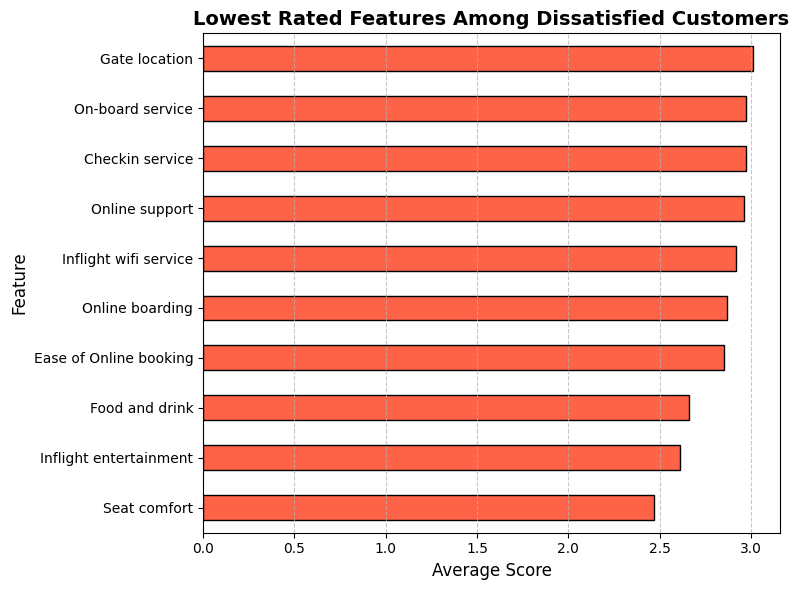

'\nDissatisfied customers consistently rate **comfort**, **entertainment**, and **digital experiences** lowest.\n\n'

In [13]:
#Take the average points (only numeric value) of dissatisfied passengers

# Filter dissatisfied passengers
dissatisfied = df[df['satisfaction'] == 0]

# Compute average values for numeric columns
dissatisfied_summary = dissatisfied.select_dtypes(include='number').mean().sort_values()

print("\nAverage numeric feature values (dissatisfied only):")
print(dissatisfied_summary.head(10))

# Drop the satisfaction column before plotting
dissatisfied_summary = dissatisfied_summary.drop(labels='satisfaction', errors='ignore')

# Visualize the lowest-rated numeric features among dissatisfied passengers
plt.figure(figsize=(8, 6))
dissatisfied_summary.head(10).plot(kind='barh', color='tomato', edgecolor='black')

plt.title("Lowest Rated Features Among Dissatisfied Customers", fontsize=14, weight='bold')
plt.xlabel("Average Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
"""
Dissatisfied customers consistently rate **comfort**, **entertainment**, and **digital experiences** lowest.

"""


Top correlated feature pairs among dissatisfied customers:
Arrival Delay in Minutes  Arrival Delay in Minutes      1.000000
                          Departure Delay in Minutes    0.968787
Ease of Online booking    Online boarding               0.813733
Online boarding           Inflight wifi service         0.781878
Ease of Online booking    Inflight wifi service         0.773925
Online support            Online boarding               0.717868
Seat comfort              Inflight entertainment        0.674772
Inflight wifi service     Online support                0.666336
Ease of Online booking    Online support                0.658538
Cleanliness               Baggage handling              0.587970
dtype: float64


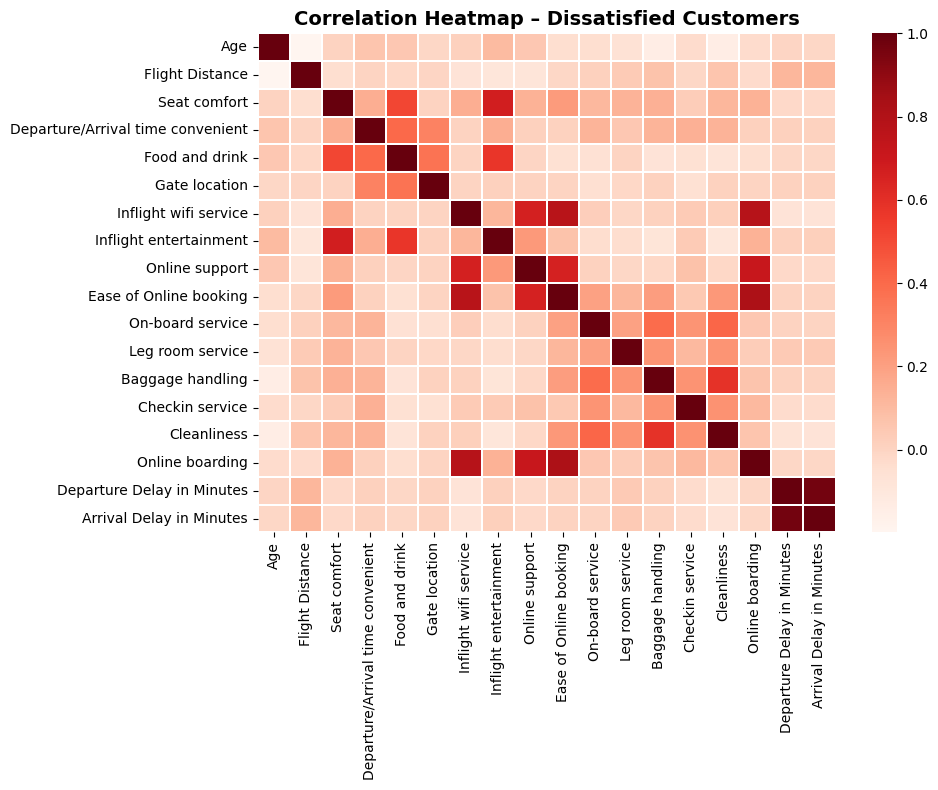

'\nKey Observations:\n-----------------\n1. **Arrival Delay ↔ Departure Delay (0.97)**\n   → Almost perfect correlation — delays are strongly linked, suggesting\n     that scheduling or operational inefficiency affects both equally.\n\n2. **Ease of Online Booking ↔ Online Boarding (0.81)**\n   → Customers who struggled with booking also faced boarding issues.\n     Indicates possible usability or integration problems in the digital system.\n\n3. **Online Boarding ↔ Inflight WiFi Service (0.78)**\n   → Dissatisfaction extends from pre-flight (boarding) into inflight digital experience.\n     Suggests that tech-savvy travelers expect seamless digital service end-to-end.\n\n4. **Ease of Online Booking ↔ Inflight WiFi (0.77)**\n   → Highlights consistency in digital pain points — booking, WiFi, and online access\n     all form a single weak link in the customer journey.\n\n5. **Online Support ↔ Online Boarding (0.72)** and **Online Support ↔ WiFi (0.67)**\n   → Digital support issues are c

In [14]:
# Filter only dissatisfied customers
dissatisfied = df[df['satisfaction'] == 0]

# Compute correlation matrix for numeric features (exclude satisfaction column)
corr_dissat = dissatisfied.select_dtypes(include='number').drop(columns='satisfaction', errors='ignore').corr()

# Display top correlations for quick inspection
print("\nTop correlated feature pairs among dissatisfied customers:")
print(corr_dissat.unstack().sort_values(ascending=False).drop_duplicates().head(10))

# --- Create heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr_dissat, cmap='Reds', annot=False, linewidths=0.3)
plt.title("Correlation Heatmap – Dissatisfied Customers", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

"""
Key Observations:
-----------------
1. **Arrival Delay ↔ Departure Delay (0.97)**
   → Almost perfect correlation — delays are strongly linked, suggesting
     that scheduling or operational inefficiency affects both equally.

2. **Ease of Online Booking ↔ Online Boarding (0.81)**
   → Customers who struggled with booking also faced boarding issues.
     Indicates possible usability or integration problems in the digital system.

3. **Online Boarding ↔ Inflight WiFi Service (0.78)**
   → Dissatisfaction extends from pre-flight (boarding) into inflight digital experience.
     Suggests that tech-savvy travelers expect seamless digital service end-to-end.

4. **Ease of Online Booking ↔ Inflight WiFi (0.77)**
   → Highlights consistency in digital pain points — booking, WiFi, and online access
     all form a single weak link in the customer journey.

5. **Online Support ↔ Online Boarding (0.72)** and **Online Support ↔ WiFi (0.67)**
   → Digital support issues are correlated with other online services,
     meaning if support fails, the entire digital experience is perceived as poor.

6. **Seat Comfort ↔ Inflight Entertainment (0.67)**
   → Physical comfort and entertainment are strongly tied — passengers who are uncomfortable
     are also less likely to enjoy or rate entertainment highly.

7. **Cleanliness ↔ Baggage Handling (0.59)**
   → Operational quality issues may cluster: when handling is sloppy, cleanliness often suffers too.

Summary:
---------
• **Digital touchpoints (booking, boarding, WiFi, support)** form a single correlated cluster of dissatisfaction.
• **Physical comfort (seat + entertainment)** is another linked pain area.
• **Operational reliability (delays, baggage, cleanliness)** represents the third group of issues.

In short: dissatisfied customers tend to experience *groups* of problems, not isolated ones.
Improving any one cluster (digital, comfort, or operations) can create a noticeable lift in satisfaction.
"""

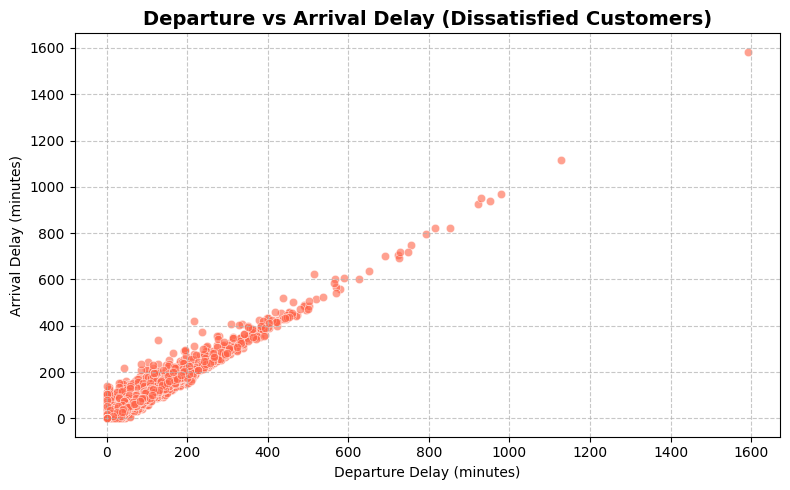

In [15]:
# Filter dissatisfied passengers
dissatisfied = df[df['satisfaction'] == 0]

# Scatter plot for delay relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Departure Delay in Minutes',
    y='Arrival Delay in Minutes',
    data=dissatisfied,
    color='tomato',
    alpha=0.6
)

plt.title("Departure vs Arrival Delay (Dissatisfied Customers)", fontsize=14, weight='bold')
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Optimization terminated successfully.
         Current function value: 0.573154
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        dissatisfaction   No. Observations:               129880
Model:                          Logit   Df Residuals:                   129873
Method:                           MLE   Df Model:                            6
Date:                Fri, 14 Nov 2025   Pseudo R-squ.:                  0.1677
Time:                        01:41:46   Log-Likelihood:                -74441.
converged:                       True   LL-Null:                       -89443.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          4.3444      0.034    128.581      0.000      

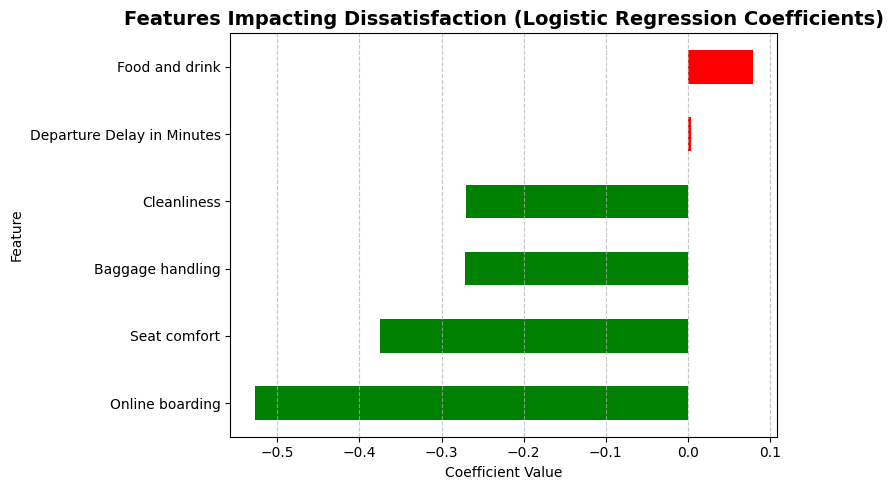

'\nPositive coefficient → higher food/drink score slightly increases likelihood of dissatisfaction\nBetter baggage handling reduces dissatisfaction.\nMost influential — smooth online boarding significantly reduces dissatisfaction.\n\n'

In [16]:
# Create target column for dissatisfaction
df['dissatisfaction'] = 1 - df['satisfaction']  # 1 = dissatisfied, 0 = satisfied

# Select key predictor features
cols = ['Seat comfort','Food and drink','Baggage handling',
        'Cleanliness','Online boarding','Departure Delay in Minutes']

X = df[cols]
X = sm.add_constant(X)  # add intercept
y = df['dissatisfaction']

# Fit logistic regression
model = sm.Logit(y, X).fit()
print(model.summary())

# Extract coefficients from model (excluding constant)
coefs = model.params.drop('const')

# Sort by magnitude for easier visualization
coefs_sorted = coefs.sort_values()

# Plot
plt.figure(figsize=(8, 5))
coefs_sorted.plot(kind='barh', color=['red' if c > 0 else 'green' for c in coefs_sorted])

plt.title("Features Impacting Dissatisfaction (Logistic Regression Coefficients)", fontsize=14, weight='bold')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


"""
Positive coefficient → higher food/drink score slightly increases likelihood of dissatisfaction
Better baggage handling reduces dissatisfaction.
Most influential — smooth online boarding significantly reduces dissatisfaction.

"""

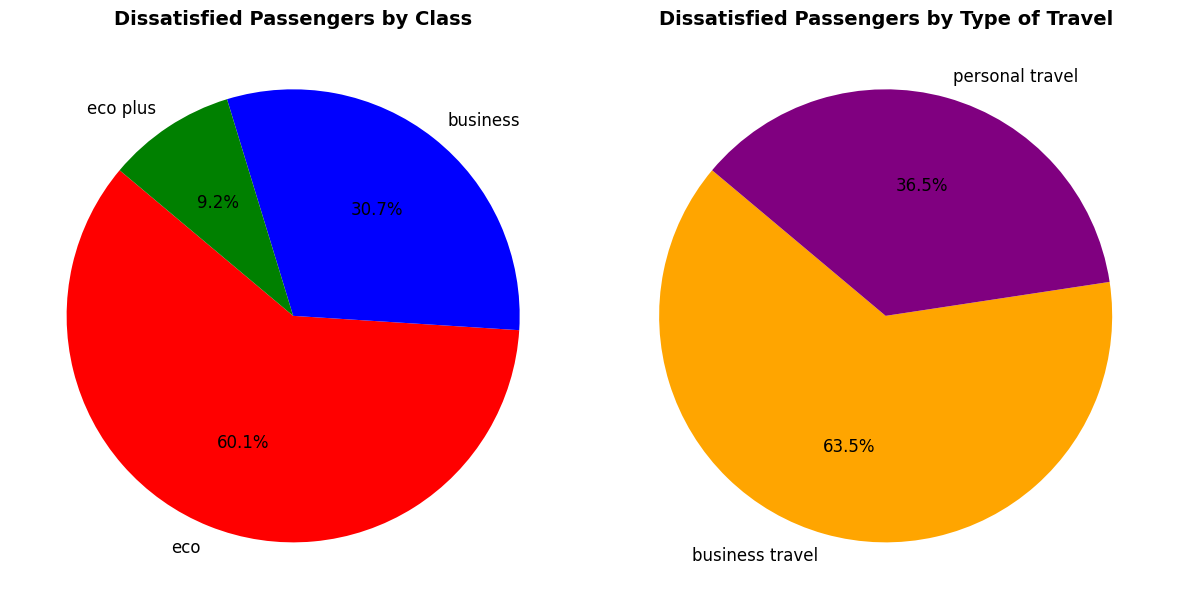

'\n\nSurprisingly, **business travelers** are more likely to be dissatisfied than personal travelers.\n   → Indicates that **business travelers have higher expectations**, especially regarding **timeliness, digital experience, and premium services**.\n→ Majority of dissatisfaction comes from **Economy class**.\n   → Suggests that **comfort, seat space, and inflight services** in Economy are key pain points.\n\n'

In [17]:
# Filter dissatisfied passengers
dissatisfied = df[df['satisfaction'] == 0]

# Proportion by Class
class_prop = dissatisfied['Class'].value_counts(normalize=True)

# Proportion by Type of Travel
type_prop = dissatisfied['Type of Travel'].value_counts(normalize=True)

# Side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for Class
axes[0].pie(class_prop, labels=class_prop.index, autopct='%1.1f%%',
            startangle=140, colors=['red','blue','green'], textprops={'fontsize':12})
axes[0].set_title("Dissatisfied Passengers by Class", fontsize=14, weight='bold')

# Pie chart for Type of Travel
axes[1].pie(type_prop, labels=type_prop.index, autopct='%1.1f%%',
            startangle=140, colors=['orange','purple'], textprops={'fontsize':12})
axes[1].set_title("Dissatisfied Passengers by Type of Travel", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

"""

Surprisingly, **business travelers** are more likely to be dissatisfied than personal travelers.
   → Indicates that **business travelers have higher expectations**, especially regarding **timeliness, digital experience, and premium services**.
→ Majority of dissatisfaction comes from **Economy class**.
   → Suggests that **comfort, seat space, and inflight services** in Economy are key pain points.

"""

**Reason Customers Are Dissatisfied**

Customers are dissatisfied primarily because they experience clusters of related service issues rather than isolated problems. The main reasons are:

Poor digital experience

Difficulties with online booking, boarding, WiFi, and online support create frustration.

Digital issues often occur together, so one problem can cascade into multiple pain points.

Lack of comfort and inflight experience

Economy-class passengers report uncomfortable seats and limited entertainment.

Food and drink service inconsistencies add to dissatisfaction.

Operational issues

Delays in departure and arrival, poor baggage handling, and subpar cleanliness further frustrate passengers.

Business travelers are especially sensitive to these operational inefficiencies.

In short: Customers are not satisfied because the airline fails to meet expectations across digital convenience, physical comfort, and operational reliability, especially for Economy-class and business travelers.

Areas for Improvement

Digital Experience:

Improve online booking and boarding processes.

Ensure WiFi and online support are reliable and seamless.

Comfort & Inflight Services:

Upgrade seat comfort and entertainment options in Economy.

Review meal quality and service for better consistency.

Operational Reliability:

Reduce departure and arrival delays.

Improve baggage handling and cleanliness.